In [34]:
import pandas as pd
df = pd.read_csv("/Users/soesoeilyana/desktop/projects/spotify-bi-analysis/data/spotify_data.csv")
print("Строк:", df.shape[0])
print("Колонок:", df.shape[1])
df.head()

Строк: 1159764
Колонок: 20


,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [39]:
print(df.info())
print(f"Период данных: с {df['year'].min()} по {df['year'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  object 
 2   track_name        1159763 non-null  object 
 3   track_id          1159764 non-null  object 
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  object 
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          1159764 non-null  float64
 16  

In [41]:
# Удаляем дубликаты
df = df.drop_duplicates(subset=['track_name', 'artist_name'])

# Оставляем только нужный период (2010-2019)
df_decade = df[(df['year'] >= 2010) & (df['year'] <= 2019)].copy()

# Обработка пустых значений
df_decade = df_decade.dropna(subset=['genre', 'popularity'])

# Перевод длительности в минуты
df_decade['duration_min'] = df_decade['duration_ms'] / 60000

# Оставляем только нужные колонки для визуализации
cols_to_keep = [
    'track_name', 'artist_name', 'year', 'genre', 'popularity', 
    'danceability', 'energy', 'valence', 'loudness', 'duration_min'
]
df_final = df_decade[cols_to_keep]

print(f"Размер очищенного датасета: {df_final.shape}")

Размер очищенного датасета: (514990, 10)


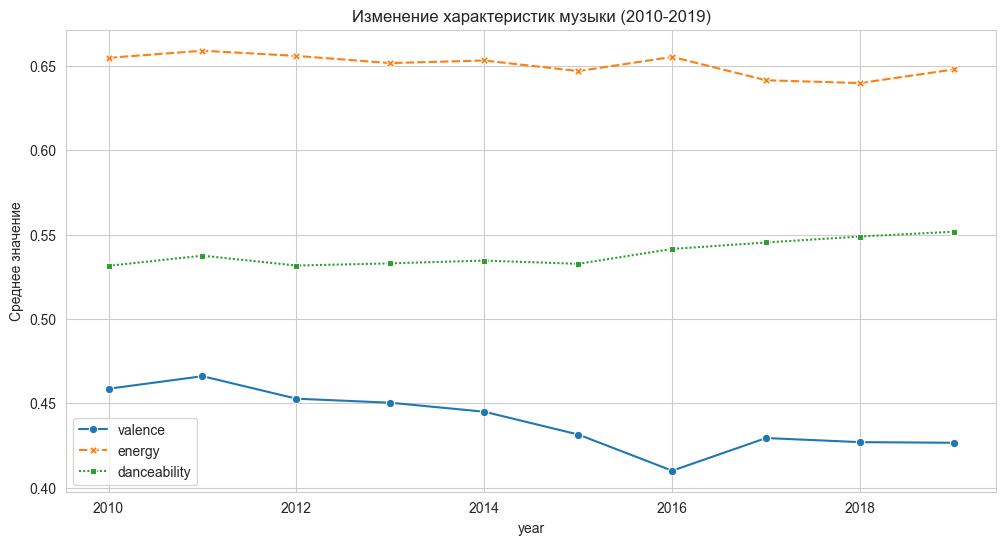

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Группируем по годам
yearly_trends = df_final.groupby('year')[['valence', 'energy', 'danceability']].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, markers=True)
plt.title("Изменение характеристик музыки (2010-2019)")
plt.ylabel("Среднее значение")
plt.grid(True)
plt.show()

In [46]:
# Выделяем топ-15 популярных жанров
top_genres = df_final['genre'].value_counts().head(15).index
df_top_genres = df_final[df_final['genre'].isin(top_genres)]

# Сохраняем результат
df_top_genres.to_csv("spotify_analysis_ready.csv", index=False)